In [1]:
# Cell 1 - Import libraries
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from PIL import Image
import os

print("✅ Libraries loaded")

✅ Libraries loaded


In [2]:
# Cell 2 - Load model and data
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Same transform as training
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], 
                         std=[0.5, 0.5, 0.5])
])

# Define model architecture again
class CIFAKE_CNN(nn.Module):
    def __init__(self):
        super(CIFAKE_CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

# Load saved model
device = torch.device('cpu')
model = CIFAKE_CNN()
model.load_state_dict(torch.load('../models/cifake_cnn.pth', 
                                  map_location=device))
model.eval()

# Load test data
test_data = datasets.ImageFolder('../data/test', transform=transform)
print(f"✅ Model loaded successfully")
print(f"✅ Test images: {len(test_data)}")

✅ Model loaded successfully
✅ Test images: 20000


In [3]:
# Cell 3 - Grad-CAM implementation
import cv2

class GradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None
        
        # Hook into last conv layer
        target_layer = model.conv_layers[10]
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_backward_hook(self.save_gradient)
    
    def save_activation(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate(self, img_tensor, label=None):
        self.model.zero_grad()
        output = self.model(img_tensor)
        output.backward()
        
        # Pool gradients
        pooled_grads = self.gradients.mean(dim=[0, 2, 3])
        activations  = self.activations[0]
        
        # Weight activations
        for i in range(activations.shape[0]):
            activations[i] *= pooled_grads[i]
        
        heatmap = activations.mean(dim=0).numpy()
        heatmap = np.maximum(heatmap, 0)
        
        # Normalize
        if heatmap.max() != 0:
            heatmap /= heatmap.max()
        
        return heatmap

print("✅ Grad-CAM class ready")

✅ Grad-CAM class ready


c:\Users\Surface Pro\Desktop\CIFAKE_MAJOR-PROJECT\venv\Lib\site-packages\torch\nn\modules\module.py:1869: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


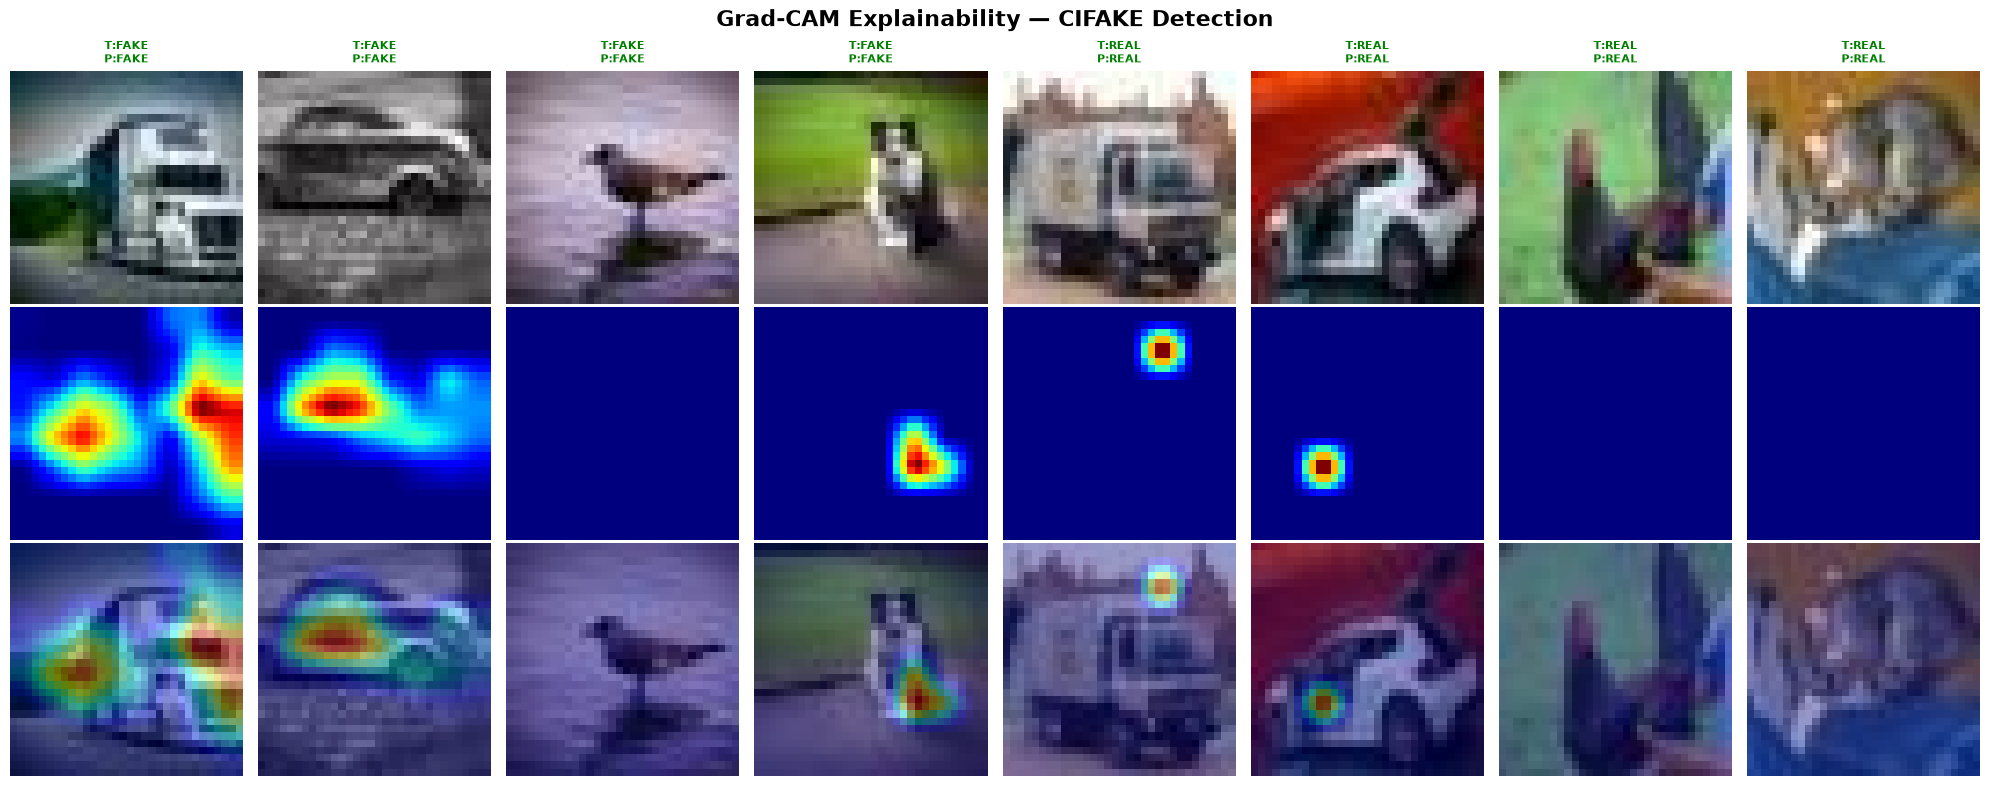

✅ Saved to outputs/gradcam_results.png


In [4]:
# Cell 4 - Visualize Grad-CAM
def denormalize(tensor):
    img = tensor.clone()
    img = img * 0.5 + 0.5
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    return img

gcam = GradCAM(model)

# Get 8 sample images - 4 REAL, 4 FAKE
real_indices = [i for i, (_, l) in enumerate(test_data) if l == 1][:4]
fake_indices = [i for i, (_, l) in enumerate(test_data) if l == 0][:4]
indices = fake_indices + real_indices

fig, axes = plt.subplots(3, 8, figsize=(20, 8))
fig.suptitle('Grad-CAM Explainability — CIFAKE Detection', 
             fontsize=16, fontweight='bold')

row_titles = ['Original', 'Heatmap', 'Overlay']
for ax, title in zip(axes[:, 0], row_titles):
    ax.set_ylabel(title, fontsize=11, fontweight='bold')

for col, idx in enumerate(indices):
    img_tensor, label = test_data[idx]
    img_tensor = img_tensor.unsqueeze(0)
    img_np     = denormalize(img_tensor[0])

    # Generate heatmap
    heatmap = gcam.generate(img_tensor)
    heatmap_resized = cv2.resize(heatmap, (32, 32))
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Overlay
    overlay = (img_np * 0.6 + heatmap_colored / 255.0 * 0.4)
    overlay = np.clip(overlay, 0, 1)

    # Predict
    with torch.no_grad():
        prob = model(img_tensor).item()
    pred  = 'REAL' if prob >= 0.5 else 'FAKE'
    true  = 'REAL' if label == 1 else 'FAKE'
    color = 'green' if pred == true else 'red'

    # Plot
    axes[0, col].imshow(img_np)
    axes[0, col].set_title(f'T:{true}\nP:{pred}', 
                            fontsize=8, color=color, fontweight='bold')
    axes[0, col].axis('off')

    axes[1, col].imshow(heatmap_resized, cmap='jet')
    axes[1, col].axis('off')

    axes[2, col].imshow(overlay)
    axes[2, col].axis('off')

plt.tight_layout()
plt.savefig('../outputs/gradcam_results.png', dpi=150)
plt.show()
print("✅ Saved to outputs/gradcam_results.png")